In [19]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [20]:
# [Cell 1.1] Data Ingestion and Preprocessing
from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Ingest Data
print("Fetching German Credit Dataset...")
# fetch_openml is the most robust way to get the exact dataset in Colab without API keys
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data

# We map 'bad' credit to 1 (the positive class representing default risk)
y = data.target.map({'good': 0, 'bad': 1})

# 2. Identify Feature Types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# 3. Construct the Preprocessing Pipeline
# 'drop="first"' ensures the design matrix has full column rank
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# 4. Execute Transformation
X_processed_array = preprocessor.fit_transform(X)

# Reconstruct DataFrame for readability and feature tracking
feature_names = preprocessor.get_feature_names_out()
X_processed = pd.DataFrame(X_processed_array, columns=feature_names)

print(f"\nPreprocessing complete. Final feature matrix shape: {X_processed.shape}")

Fetching German Credit Dataset...
Numerical features (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Preprocessing complete. Final feature matrix shape: (1000, 48)


In [21]:
# [Cell 1.2] Strict Stratified Splitting
from sklearn.model_selection import train_test_split

# First Split: Extract the untouchable Test set (20%)
# We allocate 80% to an intermediate 'Train_Val' pool
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_processed, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second Split: Partition the intermediate pool into Train (60% total) and Validation (20% total)
# Since Train_Val is 80% of the total, taking 25% of it yields 20% of the total data (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

print(f"Dataset securely partitioned:")
print(f"  Training Set   (for base models):   X: {X_train.shape}, y: {y_train.shape}")
print(f"  Validation Set (for meta-learning): X: {X_val.shape}, y: {y_val.shape}")
print(f"  Test Set       (for final eval):    X: {X_test.shape}, y: {y_test.shape}")

# Verify stratification integrity
# Fix: Cast to int to allow mean calculation on categorical data
train_ratio = y_train.astype(int).mean()
val_ratio = y_val.astype(int).mean()
test_ratio = y_test.astype(int).mean()

print(f"\nStratification Check (Proportion of 'bad' risk):")
print(f"  Train: {train_ratio:.4f} | Val: {val_ratio:.4f} | Test: {test_ratio:.4f}")

Dataset securely partitioned:
  Training Set   (for base models):   X: (600, 48), y: (600,)
  Validation Set (for meta-learning): X: (200, 48), y: (200,)
  Test Set       (for final eval):    X: (200, 48), y: (200,)

Stratification Check (Proportion of 'bad' risk):
  Train: 0.3000 | Val: 0.3000 | Test: 0.3000


In [22]:
# [Cell 2.1] Define Base Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Initialize models with fixed random states for deterministic execution
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# probability=True is mathematically required to generate the continuous [0,1] space for the ensemble
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# MLP architecture: 1 hidden layer with 64 neurons.
# ReLU activation introduces non-linearity, Adam optimizer handles weight updates.
mlp_model = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                          solver='adam', max_iter=1000, random_state=42)

base_models = {
    'Logistic_Regression': lr_model,
    'SVM': svm_model,
    'MLP': mlp_model
}

print("Base models initialized.")

Base models initialized.


In [23]:
# [Cell 2.2] K-Fold OOF Predictions and Final Training
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# Pre-allocate arrays for OOF probabilities (N_train x 3)
N_train = X_train.shape[0]
oof_P_train = np.zeros((N_train, len(base_models)))

print(f"Executing {K}-Fold Cross Validation on Train Set (N={N_train})...")

for i, (name, model) in enumerate(base_models.items()):
    oof_preds = np.zeros(N_train)

    # K-Fold loop for Out-of-Fold predictions
    for train_idx, val_idx in skf.split(X_train, y_train):
        # Extract fold specific matrices
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        # Fit on (K-1) folds
        model.fit(X_fold_train, y_fold_train)

        # Predict probability of the positive class (class 1) on the 1 holdout fold
        oof_preds[val_idx] = model.predict_proba(X_fold_val)[:, 1]

    oof_P_train[:, i] = oof_preds

    # Calculate OOF metrics
    oof_auc = roc_auc_score(y_train, oof_preds)
    print(f"  {name:20s} - OOF ROC-AUC: {oof_auc:.4f}")

    # Retrain the model on the full training set for maximum representation
    model.fit(X_train, y_train)

print("\nFinal base models trained on the complete Train set.")

Executing 5-Fold Cross Validation on Train Set (N=600)...
  Logistic_Regression  - OOF ROC-AUC: 0.7949
  SVM                  - OOF ROC-AUC: 0.7929
  MLP                  - OOF ROC-AUC: 0.7615

Final base models trained on the complete Train set.


In [24]:
# [Cell 2.3] Generate Prediction Matrix P on Validation Set
# N_val is the number of rows in the validation set.
N_val = X_val.shape[0]
P_val = np.zeros((N_val, len(base_models)))

print(f"Generating Matrix P on Validation Set (N={N_val})...")

for i, (name, model) in enumerate(base_models.items()):
    # Extract the probability of the positive class (default risk)
    P_val[:, i] = model.predict_proba(X_val)[:, 1]

print(f"Matrix P_val shape: {P_val.shape}")
print("Sample of P_val (first 3 rows):")
print(np.round(P_val[:3, :], 4))

# Explicitly assign target vector y_val for optimization blocks
y_val_array = y_val.values

Generating Matrix P on Validation Set (N=200)...
Matrix P_val shape: (200, 3)
Sample of P_val (first 3 rows):
[[0.0291 0.0798 0.0086]
 [0.1974 0.1666 0.0044]
 [0.0338 0.0387 0.    ]]


In [25]:
# [Cell 3.1] Construct QP Matrix Q and Vector c

print("Constructing Quadratic Programming matrices...")

# P_val is of shape (N_val, 3)
# y_val_array is of shape (N_val,)

# Q = 2 * P^T P
Q = 2 * np.dot(P_val.T, P_val)

# c = -2 * P^T y
# Reshape y_val_array to (N_val, 1) to ensure strict matrix algebra alignment
c = -2 * np.dot(P_val.T, y_val_array.reshape(-1, 1))

# Flatten c back to a 1D array for scipy.optimize compatibility
c = c.flatten()

print(f"Matrix Q shape: {Q.shape}")
print(Q)
print(f"\nVector c shape: {c.shape}")
print(c)

Constructing Quadratic Programming matrices...
Matrix Q shape: (3, 3)
[[69.2934186  62.03772405 68.21089958]
 [62.03772405 61.12726439 64.8439495 ]
 [68.21089958 64.8439495  96.8455308 ]]

Vector c shape: (3,)
[-55.78438393 -53.37049285 -56.48319242]


In [26]:
# [Cell 3.2] Solve for optimal ensemble weights using SLSQP
from scipy.optimize import minimize

# 1. Define the strictly formulated QP objective function
def qp_objective(w, Q, c):
    # 0.5 * w^T * Q * w + c^T * w
    quadratic_term = 0.5 * np.dot(w.T, np.dot(Q, w))
    linear_term = np.dot(c.T, w)
    return quadratic_term + linear_term

# 2. Define the equality constraint: sum of weights must equal 1
# Scipy requires constraints in the form of f(w) = 0
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1.0
})

# 3. Define the non-negativity bounds for each weight
# w_i in [0, 1] for all i
num_models = P_val.shape[1]
bounds = tuple((0.0, 1.0) for _ in range(num_models))

# 4. Initialize starting weights (e.g., uniform distribution)
w_init = np.ones(num_models) / num_models

# 5. Execute SLSQP optimization
print("Executing SLSQP solver...")
result = minimize(
    fun=qp_objective,
    x0=w_init,
    args=(Q, c),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'disp': True, 'ftol': 1e-9} # High precision tolerance
)

# 6. Extract and verify results
if result.success:
    w_QP = result.x
    print("\n--- Mathematical Benchmark Reached ---")
    print("Optimal Weights (w_QP):")
    for name, weight in zip(base_models.keys(), w_QP):
        print(f"  {name:20s}: {weight:.6f}")

    print(f"\nSum of weights: {np.sum(w_QP):.6f}")

    # Calculate continuous MSE for the optimal ensemble
    optimal_preds = np.dot(P_val, w_QP)
    # Fix: Ensure y_val_array is numeric to allow subtraction
    y_val_numeric = y_val_array.astype(float)
    mse_optimal = np.mean((optimal_preds - y_val_numeric) ** 2)
    print(f"Benchmark Ensemble Validation MSE: {mse_optimal:.6f}")
else:
    print("Optimization failed:", result.message)

Executing SLSQP solver...
Optimization terminated successfully    (Exit mode 0)
            Current function value: -22.98497116221371
            Iterations: 3
            Function evaluations: 13
            Gradient evaluations: 3

--- Mathematical Benchmark Reached ---
Optimal Weights (w_QP):
  Logistic_Regression : 0.236939
  SVM                 : 0.763061
  MLP                 : 0.000000

Sum of weights: 1.000000
Benchmark Ensemble Validation MSE: 0.185075


In [27]:
# [Cell 4.1] Define the Continuous Objective Function

def normalize_weights(w):
    """Enforces non-negativity and sum-to-one constraints."""
    w_abs = np.abs(w)
    # Add a small epsilon to prevent division by zero
    w_norm = w_abs / (np.sum(w_abs) + 1e-10)
    return w_norm

def objective_function(w, P, y):
    """
    Computes the Mean Squared Error for a given weight vector.
    P: Prediction matrix (N x 3)
    y: True labels (N,)
    """
    w_norm = normalize_weights(w)
    ensemble_preds = np.dot(P, w_norm)
    mse = np.mean((ensemble_preds - y) ** 2)
    return mse

print("Objective function and constraint normalizer defined.")

Objective function and constraint normalizer defined.


Initializing ACOR: 40 ants, 100 iterations...
  Iteration  20/100 - Best MSE: 0.185075
  Iteration  40/100 - Best MSE: 0.185075
  Iteration  60/100 - Best MSE: 0.185075
  Iteration  80/100 - Best MSE: 0.185075
  Iteration 100/100 - Best MSE: 0.185075


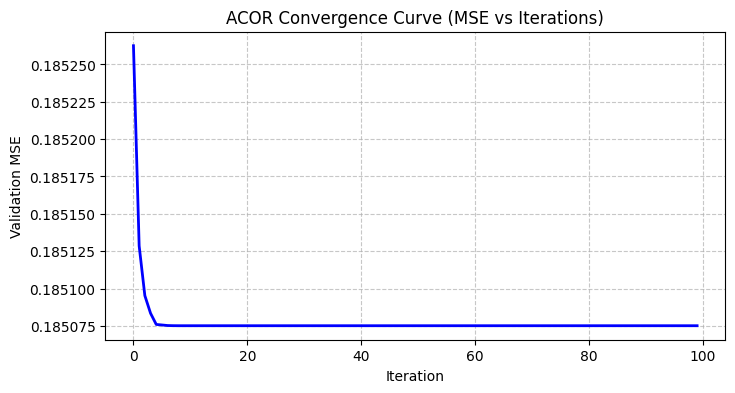

In [28]:
# [Cell 4.2] Implement Continuous Ant Colony Optimization (ACOR)
import matplotlib.pyplot as plt

def run_acor(P, y, num_models, n_ants=40, archive_size=20, iterations=100, q=0.1, xi=0.85):
    """
    q: Locality of the search process. Small q favors the best-ranked solutions strongly.
    xi: Convergence speed (analogous to pheromone evaporation).
    """
    print(f"Initializing ACOR: {n_ants} ants, {iterations} iterations...")

    # 1. Initialize the Solution Archive with random weights
    archive = np.random.rand(archive_size, num_models)
    archive = np.array([normalize_weights(w) for w in archive])

    # Evaluate initial archive
    scores = np.array([objective_function(w, P, y) for w in archive])

    # Sort archive by score (ascending, since we minimize MSE)
    sort_idx = np.argsort(scores)
    archive = archive[sort_idx]
    scores = scores[sort_idx]

    # Calculate selection probabilities based on rank (Gaussian function)
    ranks = np.arange(1, archive_size + 1)
    weights = (1 / (q * archive_size * np.sqrt(2 * np.pi))) * \
              np.exp(-((ranks - 1)**2) / (2 * (q * archive_size)**2))
    selection_probs = weights / np.sum(weights)

    convergence_curve = np.zeros(iterations)

    # 2. Main ACOR Loop
    for iter in range(iterations):
        new_solutions = np.zeros((n_ants, num_models))
        new_scores = np.zeros(n_ants)

        for ant in range(n_ants):
            # Choose a guiding solution from the archive based on selection_probs
            guide_idx = np.random.choice(archive_size, p=selection_probs)
            guide_solution = archive[guide_idx]

            # Calculate dynamic standard deviation (sigma) for the Gaussian kernel
            # Sigma is proportional to the average distance to other solutions in the archive
            sigma = xi * np.sum(np.abs(archive - guide_solution), axis=0) / (archive_size - 1)

            # Sample new continuous weights
            sampled_w = np.random.normal(loc=guide_solution, scale=sigma)
            sampled_w = normalize_weights(sampled_w)

            new_solutions[ant] = sampled_w
            new_scores[ant] = objective_function(sampled_w, P, y)

        # 3. Update Archive
        # Combine old archive and new solutions
        combined_archive = np.vstack((archive, new_solutions))
        combined_scores = np.concatenate((scores, new_scores))

        # Sort and keep the best `archive_size` solutions
        sort_idx = np.argsort(combined_scores)
        archive = combined_archive[sort_idx][:archive_size]
        scores = combined_scores[sort_idx][:archive_size]

        # Track best MSE
        convergence_curve[iter] = scores[0]

        if (iter + 1) % 20 == 0:
            print(f"  Iteration {iter+1:3d}/{iterations} - Best MSE: {scores[0]:.6f}")

    return archive[0], scores[0], convergence_curve

# Execute the algorithm
num_base_models = P_val.shape[1]
# Fix: Explicitly cast y_val_array to float to avoid categorical subtraction error
y_val_numeric = y_val_array.astype(float)
w_ACO_raw, mse_ACO, convergence = run_acor(P_val, y_val_numeric, num_models=num_base_models)
w_ACO = normalize_weights(w_ACO_raw)

# Plot convergence for strict performance verification
plt.figure(figsize=(8, 4))
plt.plot(convergence, color='blue', linewidth=2)
plt.title('ACOR Convergence Curve (MSE vs Iterations)')
plt.xlabel('Iteration')
plt.ylabel('Validation MSE')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [29]:
# [Cell 4.3] Compare w_ACO with w_QP
print("--- Weight Optimization Comparison ---")
print(f"{'Model':<25} | {'QP Weights':<15} | {'ACO Weights':<15}")
print("-" * 60)

for idx, name in enumerate(base_models.keys()):
    print(f"{name:<25} | {w_QP[idx]:<15.6f} | {w_ACO[idx]:<15.6f}")

print("-" * 60)
print(f"{'Validation MSE':<25} | {mse_optimal:<15.6f} | {mse_ACO:<15.6f}")

# Calculate the Euclidean distance between the two weight vectors
l2_distance = np.linalg.norm(w_QP - w_ACO)
print(f"\nL2 Norm (Euclidean Distance) between w_QP and w_ACO: {l2_distance:.6f}")

if l2_distance < 0.05:
    print("Conclusion: ACOR successfully converged near the global mathematical optimum.")
else:
    print("Conclusion: ACOR found a sub-optimal local minimum. Consider tuning 'q' and 'xi' parameters.")

--- Weight Optimization Comparison ---
Model                     | QP Weights      | ACO Weights    
------------------------------------------------------------
Logistic_Regression       | 0.236939        | 0.236939       
SVM                       | 0.763061        | 0.763061       
MLP                       | 0.000000        | 0.000000       
------------------------------------------------------------
Validation MSE            | 0.185075        | 0.185075       

L2 Norm (Euclidean Distance) between w_QP and w_ACO: 0.000000
Conclusion: ACOR successfully converged near the global mathematical optimum.


In [30]:
# [Cell 5.1] Define Custom 1D ANFIS Architecture in PyTorch

import torch.nn as nn
import torch.nn.functional as F

class GaussianMF(nn.Module):
    def __init__(self, centers, sigmas):
        super(GaussianMF, self).__init__()
        # centers and sigmas are initialized as learnable parameters
        self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32))
        self.sigmas = nn.Parameter(torch.tensor(sigmas, dtype=torch.float32))

    def forward(self, x):
        # x shape: (batch_size, 1)
        # Output shape: (batch_size, num_rules)
        return torch.exp(-0.5 * ((x - self.centers) / self.sigmas) ** 2)

class ANFIS1D(nn.Module):
    def __init__(self):
        super(ANFIS1D, self).__init__()
        # Initialize 3 rules: Low, Medium, High risk
        # We intuitively distribute the initial centers across the [0, 1] probability space
        initial_centers = [0.1, 0.5, 0.9]
        initial_sigmas = [0.2, 0.2, 0.2]

        self.fuzzify = GaussianMF(initial_centers, initial_sigmas)

        # Consequent parameters for First-Order Takagi-Sugeno
        # For 3 rules, we need 3 'a' parameters and 3 'b' parameters
        self.a = nn.Parameter(torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32))

    def forward(self, x):
        # 1. Fuzzification
        w = self.fuzzify(x) # Shape: (batch_size, 3)

        # 2. Normalization
        w_sum = torch.sum(w, dim=1, keepdim=True)
        # Add epsilon to prevent division by zero
        w_norm = w / (w_sum + 1e-8)

        # 3. Consequent Evaluation (f_i = a_i * x + b_i)
        # x is (batch_size, 1), a and b are (3,)
        f = x * self.a + self.b # Shape: (batch_size, 3)

        # 4. Final Output Calculation
        output = torch.sum(w_norm * f, dim=1) # Shape: (batch_size,)
        return output

print("Takagi-Sugeno ANFIS model architecture defined.")

Takagi-Sugeno ANFIS model architecture defined.


In [31]:
# [Cell 5.2] Train ANFIS Model on Validation Set
import torch.optim as optim

# 1. Prepare the data
# Generate the optimized continuous predictions using w_ACO
ensemble_preds_val = np.dot(P_val, w_ACO)

# Convert to PyTorch tensors
X_tensor = torch.tensor(ensemble_preds_val, dtype=torch.float32).view(-1, 1)
y_tensor = torch.tensor(y_val_array, dtype=torch.float32)

# 2. Initialize Model, Loss, and Optimizer
anfis_model = ANFIS1D()
criterion = nn.MSELoss()
# Adam optimizer handles both premise (centers/sigmas) and consequent (a/b) parameters
optimizer = optim.Adam(anfis_model.parameters(), lr=0.01)

# 3. Training Loop
epochs = 500
print("Initiating ANFIS Hybrid Learning...")

for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward pass
    outputs = anfis_model(X_tensor)

    # Compute loss
    loss = criterion(outputs, y_tensor)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"  Epoch {epoch+1:3d}/{epochs} - Loss (MSE): {loss.item():.6f}")

print("\n--- ANFIS Training Complete ---")

# 4. Extract and print the learned fuzzy rules for interpretability
learned_centers = anfis_model.fuzzify.centers.detach().numpy()
learned_sigmas = anfis_model.fuzzify.sigmas.detach().numpy()

print("\nLearned Linguistic Variables (Gaussian MFs):")
print(f"  Rule 1 (Low Risk):    Center = {learned_centers[0]:.4f}, Sigma = {learned_sigmas[0]:.4f}")
print(f"  Rule 2 (Medium Risk): Center = {learned_centers[1]:.4f}, Sigma = {learned_sigmas[1]:.4f}")
print(f"  Rule 3 (High Risk):   Center = {learned_centers[2]:.4f}, Sigma = {learned_sigmas[2]:.4f}")

# Function to map a probability to a linguistic interpretation based on max membership
def interpret_risk(p_val):
    p_tensor = torch.tensor([[p_val]], dtype=torch.float32)
    memberships = anfis_model.fuzzify(p_tensor).detach().numpy()[0]
    rule_idx = np.argmax(memberships)
    labels = ["Low Risk", "Medium Risk", "High Risk"]
    return labels[rule_idx], memberships

print("\nExample Interpretations:")
sample_probs = [0.15, 0.45, 0.85]
for p in sample_probs:
    label, mems = interpret_risk(p)
    print(f"  Ensemble Prob {p:.2f} -> {label} (Memberships: L:{mems[0]:.2f}, M:{mems[1]:.2f}, H:{mems[2]:.2f})")

Initiating ANFIS Hybrid Learning...
  Epoch 100/500 - Loss (MSE): 0.180984
  Epoch 200/500 - Loss (MSE): 0.180773
  Epoch 300/500 - Loss (MSE): 0.180751
  Epoch 400/500 - Loss (MSE): 0.180725
  Epoch 500/500 - Loss (MSE): 0.180678

--- ANFIS Training Complete ---

Learned Linguistic Variables (Gaussian MFs):
  Rule 1 (Low Risk):    Center = -0.0752, Sigma = 0.0193
  Rule 2 (Medium Risk): Center = 0.4681, Sigma = 0.1582
  Rule 3 (High Risk):   Center = 0.9570, Sigma = 0.3337

Example Interpretations:
  Ensemble Prob 0.15 -> Medium Risk (Memberships: L:0.00, M:0.13, H:0.05)
  Ensemble Prob 0.45 -> Medium Risk (Memberships: L:0.00, M:0.99, H:0.32)
  Ensemble Prob 0.85 -> High Risk (Memberships: L:0.00, M:0.05, H:0.95)


In [32]:
# [Cell 6] Final Evaluation Pipeline
print("Initiating Final Test Phase on untouched data...")

# ---------------------------------------------------------
# Cell 6.1: Run the Test set through the Base Models
# ---------------------------------------------------------
N_test = X_test.shape[0]
P_test = np.zeros((N_test, len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    # Extract probability of the positive class (class 1: default risk)
    P_test[:, i] = model.predict_proba(X_test)[:, 1]

print(f"Base model predictions generated. Matrix P_test shape: {P_test.shape}")

Initiating Final Test Phase on untouched data...
Base model predictions generated. Matrix P_test shape: (200, 3)


In [33]:
# ---------------------------------------------------------
# Cell 6.2: Apply w_ACO for final ML prediction score
# ---------------------------------------------------------
# final_test_probs is the continuous array p in [0, 1]
final_test_probs = np.dot(P_test, w_ACO)
print("ACO-optimized weights applied to test predictions.")

ACO-optimized weights applied to test predictions.


In [34]:
# ---------------------------------------------------------
# Cell 6.3: ANFIS Interpretability Mapping
# ---------------------------------------------------------
# Convert probabilities to PyTorch tensor for the ANFIS fuzzification layer
test_probs_tensor = torch.tensor(final_test_probs, dtype=torch.float32).view(-1, 1)

# Pass through the trained Gaussian membership functions
memberships = anfis_model.fuzzify(test_probs_tensor).detach().numpy()

# Determine the linguistic risk class by taking the argmax of the membership degrees
rule_indices = np.argmax(memberships, axis=1)
risk_categories = np.array(["Low Risk", "Medium Risk", "High Risk"])
final_risk_labels = risk_categories[rule_indices]

print("ANFIS linguistic mapping complete.")

ANFIS linguistic mapping complete.


In [35]:
# ---------------------------------------------------------
# Cell 6.4: Output Strict Classification Metrics
# ---------------------------------------------------------
# Standard machine learning classification requires a hard threshold (p >= 0.5)
binary_predictions = (final_test_probs >= 0.5).astype(int)
y_test_array = y_test.values

# Calculate scalar metrics
precision = precision_score(y_test_array, binary_predictions)
recall = recall_score(y_test_array, binary_predictions)
f1 = f1_score(y_test_array, binary_predictions)
roc_auc = roc_auc_score(y_test_array, final_test_probs)
conf_matrix = confusion_matrix(y_test_array, binary_predictions)

print("\n" + "="*50)
print("FINAL ENSEMBLE TEST METRICS (ACO + ANFIS)")
print("="*50)
print(f"ROC-AUC Score: {roc_auc:.4f}  <- (Primary metric for probability separation)")
print(f"Precision:     {precision:.4f}  <- (When predicting Bad Risk, how often is it correct?)")
print(f"Recall:        {recall:.4f}  <- (Out of all actual Bad Risks, how many were found?)")
print(f"F1-Score:      {f1:.4f}  <- (Harmonic mean of Precision and Recall)")
print("-" * 50)
print("Confusion Matrix:")
print(f"True Negatives (Good predicted Good):  {conf_matrix[0, 0]}")
print(f"False Positives (Good predicted Bad):  {conf_matrix[0, 1]}")
print(f"False Negatives (Bad predicted Good):  {conf_matrix[1, 0]}")
print(f"True Positives (Bad predicted Bad):    {conf_matrix[1, 1]}")
print("="*50)

# ---------------------------------------------------------
# Display a sample of the integrated architecture output
# ---------------------------------------------------------
print("\nSample Pipeline Output (First 10 instances):")
results_df = pd.DataFrame({
    'True Label': y_test_array[:10],
    'ACO ML Prob': np.round(final_test_probs[:10], 4),
    'Binary Pred': binary_predictions[:10],
    'ANFIS Risk Class': final_risk_labels[:10]
})
print(results_df.to_string(index=False))


FINAL ENSEMBLE TEST METRICS (ACO + ANFIS)
ROC-AUC Score: 0.7906  <- (Primary metric for probability separation)
Precision:     0.6538  <- (When predicting Bad Risk, how often is it correct?)
Recall:        0.5667  <- (Out of all actual Bad Risks, how many were found?)
F1-Score:      0.6071  <- (Harmonic mean of Precision and Recall)
--------------------------------------------------
Confusion Matrix:
True Negatives (Good predicted Good):  122
False Positives (Good predicted Bad):  18
False Negatives (Bad predicted Good):  26
True Positives (Bad predicted Bad):    34

Sample Pipeline Output (First 10 instances):
True Label  ACO ML Prob  Binary Pred ANFIS Risk Class
         0       0.1951            0      Medium Risk
         0       0.0897            0      Medium Risk
         1       0.7164            1        High Risk
         0       0.4685            0      Medium Risk
         1       0.2193            0      Medium Risk
         0       0.2025            0      Medium Risk
  